In [1]:
import os
import sys 

import numpy as np
import pandas as pd
pd.set_option('display.max_columns', 500)
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline
import geopandas as gpd

# CVI

In [2]:
cvi_ind = pd.read_csv('src/CVI/CVI_indicators_current.csv')
cvi_ind.head()

,Indicator Name,Adverse Direction,Replace NA with median,Category,Subcategory,Parameters,Agency or data source,Year of data release,Geographic Level,GeographicScale
0,Life Expectancy,-1.0,1,Health,Overall Physical Health,Life Expectancy,Policy Map,2010-2015,Census Tract,Tract
1,Physical health not good for >=14 days among adults aged >=18 years,1.0,1,Health,Overall Physical Health,Self-Reported Physical Health,"PLACES (BRFSS, RWJ, CDC)","BRFSS 2019 or 2018, Census Bureau 2010 data, and ACS 2015–2019 or 2014–2018 estimates.",Census Tract (Model based),Tract
2,Mental health not good for >=14 days among adults aged >=18 years,1.0,1,Health,Mental Health & Deaths of Despair,Self-Reported Mental Health,"PLACES (BRFSS, RWJ, CDC)","BRFSS 2019 or 2018, Census Bureau 2010 data, and ACS 2015–2019 or 2014–2018 estimates.",Census Tract (Model based),Tract
3,Fatal Drug Overdose,1.0,1,Health,Mental Health & Deaths of Despair,"Drug Overdose Deaths per 100,000 People",County Health Rankings & Roadmaps,2021,Census Tract,County
4,Binge drinking among adults aged >=18 years,1.0,1,Health,Mental Health & Deaths of Despair,Alcohol Abuse,"PLACES (BRFSS, RWJ, CDC)","BRFSS 2019 or 2018, Census Bureau 2010 data, and ACS 2015–2019 or 2014–2018 estimates.",Census Tract (Model based),Tract


In [4]:
cvi_ind[cvi_ind['Indicator Name'].str.contains('Diversity')]

,Indicator Name,Adverse Direction,Replace NA with median,Category,Subcategory,Parameters,Agency or data source,Year of data release,Geographic Level,GeographicScale


In [4]:
cvi_ind['Category'].unique()

array(['Health', 'Social & Economic', 'Infrastructure', 'Environment',
       'CC: Health', 'CC: Social & Economic', 'CC: Extreme Events'],
      dtype=object)

In [7]:
cvi_ind[cvi_ind['Category'] == 'Infrastructure']

,Indicator Name,Adverse Direction,Replace NA with median,Category,Subcategory,Parameters,Agency or data source,Year of data release,Geographic Level,GeographicScale
70,Congestion,1.0,0,Infrastructure,Transportation,Delay (congestion) per capita/census tract,NaN,NaN,Census Tract,Tract
71,Flooded roads,1.0,1,Infrastructure,Transportation,Flooding risk to roads,NaN,NaN,Census Tract,Tract
72,Lane Mile per Capita,-1.0,0,Infrastructure,Transportation,Lane miles per capita,NaN,NaN,Census Tract,Tract
73,Road Quality/ Maintenance,1.0,1,Infrastructure,Transportation,Road Quality and Maintenance,VMT weighted International Roughness Index (IRI),NaN,Census Tract,Tract
74,Transit Performance Score,-1.0,1,Infrastructure,Transportation,Public Transit Performance,NaN,NaN,Census Tract,Tract
75,Bridge Quality,-1.0,0,Infrastructure,Transportation,Bridge Quality and Maintenance,NaN,NaN,Census Tract,Tract
76,Walkability,-1.0,1,Infrastructure,Transportation,Walkability,NaN,NaN,Census Tract,Tract
77,Bikability,-1.0,1,Infrastructure,Transportation,Bikability,NaN,NaN,Census Tract,Tract
78,Residential Energy Cost Burden,1.0,1,Infrastructure,Energy,Residential Energy Cost Burden,Office of Energy Efficiency & Renewable Energy,2018,Census Tract,Tract
79,Fossil Fuel Generation,1.0,1,Infrastructure,Energy,Share of energy from fossil fuels,Policy Map,2019,County,County


In [7]:
cvi = pd.read_csv('src/CVI/CVI_master.csv')
cvi

,Path To File,GEOID Column Name,Data Column Name,Subset Column Name,Indicator Name,Adverse Direction,Replace NA with median,Clean/Final Data,Converted to Tract?,Category,...,URL,Download Date,Geographic Level,Missing States?,Document Name & Dropbox Link,File Type,Notes,Verified,FracTractsNA,GeographicScale
0,"Baseline Vulnerability, Health/Health/LifeExpectancy.CSV",FIPS Code,"Life expectancy at birth, as of 2010-2015.",NaN,Life Expectancy,-1.0,1,YES,NaN,Health,...,NaN,44413,Census Tract,NaN,LifeExpectancy,CSV,W Verified. This is a rate.,True,0.080882,Tract
1,"Baseline Vulnerability, Health/Health/PLACES__Local_Data_for_Better_Health__Census_Tract_Data_20...",LocationName,Data_Value,Measure,Physical health not good for >=14 days among adults aged >=18 years,1.0,1,YES,NaN,Health,...,Link,44551,Census Tract (Model based),NaN,PLACES__Local_Data_for_Better_Health__Census_Tract_Data_2021_release,CSV,5/25 - NJ included in 2020 data release. 5/17: Missing NJ. W Verified. This is a % per total pop...,True,0.010198,Tract
2,"Baseline Vulnerability, Health/Health/PLACES__Local_Data_for_Better_Health__Census_Tract_Data_20...",LocationName,Data_Value,Measure,Mental health not good for >=14 days among adults aged >=18 years,1.0,1,YES,NaN,Health,...,Link,44551,Census Tract (Model based),NaN,PLACES__Local_Data_for_Better_Health__Census_Tract_Data_2021_release,CSV,5/25 - NJ included in 2020 data release. 5/17: Missing NJ. W Verified. This is a % per total pop...,True,0.010198,Tract
3,"Baseline Vulnerability, Health/Health/CTY_HEALTH_2021_GTL.csv",FIPS,NEW_DRUG_OD_DEATH_RATE,NaN,Fatal Drug Overdose,1.0,1,YES,NaN,Health,...,Link,44760,Census Tract,NaN,CTY_HEALTH_2021_GTL,CSV,5/25: Still many NAs (including all of NJ). W Verified. This is a rate. \r\n4/4 update: Sharmila...,True,0.000068,County
4,"Baseline Vulnerability, Health/Health/PLACES__Local_Data_for_Better_Health__Census_Tract_Data_20...",LocationName,Data_Value,Measure,Binge drinking among adults aged >=18 years,1.0,1,YES,NaN,Health,...,Link,44551,Census Tract (Model based),NaN,PLACES__Local_Data_for_Better_Health__Census_Tract_Data_2021_release,CSV,5/25 - NJ included in 2020 data release. 5/17: Missing NJ. W Verified. This is a % per total pop...,True,0.010198,Tract
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179,"Climate Change Impacts, Extreme Events/NRI_Table_CensusTracts.csv",GEOID10,RFLD_AFREQ,NaN,Riverine Flooding,1.0,0,NaN,NaN,CC: Extreme Events,...,Link,NaN,Tract Level,NaN,see filepath,NaN,HISTORICAL\r\n5/25: W added this,True,0.004366,Tract
180,"Climate Change Impacts, Extreme Events/NOAA NCDC Severe Weather Events/SLR_Coastal_zonalstat.csv",GEOID10,SLRmean,NaN,SLR: Sea Level Rise (unit = meters),1.0,0,NaN,NaN,CC: Extreme Events,...,Link,NaN,Tract Level processed from rasters,NaN,SLR_Coastal_zonalstat,CSV,"PROJECTED\r\n5/17: Check - Some coastal areas seem excluded (e.g., around Galveston??) - Aurora ...",True,0.914505,Tract (raster)
181,"Climate Change Impacts, Extreme Events/NRI_Table_CensusTracts.csv",GEOID10,HRCN_AFREQ,NaN,Hurricanes,1.0,0,NaN,NaN,CC: Extreme Events,...,Link,NaN,Tract Level,NaN,see filepath,CSV,HISTORICAL\r\nW Verified. About 1/4 NA - OK to replace by 0? JP: please verify. Now using FEMA N...,True,0.236569,Tract
182,"Climate Change Impacts, Extreme Events/NRI_Table_CensusTracts.csv",GEOID10,TRND_AFREQ,NaN,Tornadoes,1.0,1,NaN,NaN,CC: Extreme Events,...,Link,NaN,Tract Level,NaN,see filepath,CSV,HISTORICAL\r\nW Verified. JP: please verify. Now using FEMA NRI instead of NCDC data for extreme...,True,0.004366,Tract


# LDT

In [24]:
df = pd.read_csv("D:\Work\WB\LDT\countries\SRB\datasets\RS_processed-data_full-indicator-list.csv".replace('\\', '/'))
df['railway_length_flood_risk'] = df['railway_length_flood_risk'] / 1000
df['road_length_flood_risk'] = df['road_length_flood_risk'] / 1000

# df = pd.read_csv("D:\Work\WB\LDT\countries\SRB\datasets\SRB_full_absolute.csv".replace('\\', '/'))
df

,GID_2,NAME_2,year,hospital_accesibility,school_accesibility,pm25_concentration,o3_concentration,co2e_20yr_emissions_quantity,co2e_20yr_emissions_factor,agriculture_emissions,forestry-and-land-use_emissions,total_powerplant_coal_emissions_quantity,assets_broadband_speed_target,avg_d_mbps_broadband,key_structures_without_internet,healthcare-facilities-diversity,luminosity,avg_d_mbps_mobile,railway_length_flood_risk,road_length_flood_risk,population_sum,rail_length_flood_pcap,road_length_flood_pcap,rail_length_heatwave_risk,road_length_heatwave_risk,rail_length_pcap_heatwave,road_length_pcap_heatwave
0,SRB.1.1_1,Bor,2022,68.0,67.0,8.200826,83.223843,2.426913e+05,0.001949,34427.619023,-3.271693e+05,0.0,70.00,52.114375,0.000000,1.388204,49666.750000,36.962571,0.00000,0.000000,36938.533333,0.000,0.000,91.160238,2990.901095,0.002468,0.080970
1,SRB.1.2_1,Kladovo,2022,0.0,0.0,8.020168,82.699687,-4.477292e+05,0.001291,25194.353584,-4.797092e+05,0.0,100.00,59.009417,0.000000,-0.000000,22002.450000,29.269801,0.00000,224.386815,16626.023529,0.000,13.496,0.000000,1389.346154,0.000000,0.083565
2,SRB.1.3_1,Majdanpek,2022,33.0,12.0,8.813018,81.591422,-4.353125e+05,0.001944,22611.298330,-4.671388e+05,0.0,50.00,48.167000,20.000000,1.039721,17438.500000,43.221584,0.00000,115.498788,13804.294118,0.000,8.367,48.239500,2155.660005,0.003495,0.156159
3,SRB.1.4_1,Negotin,2022,10.0,3.0,8.931743,79.895999,-1.574552e+06,0.001902,201050.222273,-1.775602e+06,0.0,0.00,18.188750,0.000000,0.759547,31368.900000,40.925646,59.20766,394.397557,28860.266667,2.052,13.666,85.573661,2562.409002,0.002965,0.088787
4,SRB.10.1_1,Aleksinac,2022,58.0,44.0,10.482962,85.749346,1.065689e+05,0.001839,29474.009024,7.709493e+04,0.0,15.87,20.851130,85.294118,1.141857,72620.000000,39.859882,0.00000,162.341903,38180.529412,0.000,4.252,130.325627,2912.461398,0.003413,0.076281
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,SRB.8.8_1,Vladimirci,2022,18.0,1.0,11.244723,84.628065,-4.484253e+03,0.001899,20415.419407,-2.489967e+04,0.0,0.00,0.000000,0.000000,-0.000000,19276.200000,31.139746,0.00000,46.006503,11372.007843,0.000,4.046,0.000000,1220.596216,0.000000,0.107333
157,SRB.9.1_1,Čačak,2022,0.0,72.0,9.239583,79.494700,1.353657e+04,0.001158,25900.987589,-1.121057e+05,0.0,90.91,87.723295,0.000000,0.693147,168891.100000,43.197736,0.00000,0.000000,100761.901961,0.000,0.000,124.502613,3313.504598,0.001236,0.032884
158,SRB.9.2_1,GornjiMilanovac,2022,0.0,8.0,10.745974,79.423444,-7.987157e+04,0.001198,31204.141414,-1.954477e+05,0.0,70.00,70.044125,25.000000,1.214890,48741.500000,47.382354,0.00000,0.000000,33296.015686,0.000,0.000,0.000000,3336.028058,0.000000,0.100193
159,SRB.9.3_1,Ivanjica,2022,0.0,9.0,NaN,NaN,-4.100119e+05,0.001461,13053.641361,-4.495253e+05,0.0,0.00,14.211500,0.000000,-0.000000,21512.600000,32.594573,0.00000,0.000000,22514.325490,0.000,0.000,0.000000,3628.609837,0.000000,0.161169


## Missing Percentage

In [25]:
missing_df = pd.DataFrame({
    'column': df.columns,
    'missing_pct': df.isnull().mean()*100 
})

missing_df

,column,missing_pct
GID_2,GID_2,0.000000
NAME_2,NAME_2,0.000000
year,year,0.000000
hospital_accesibility,hospital_accesibility,0.000000
school_accesibility,school_accesibility,0.000000
pm25_concentration,pm25_concentration,0.621118
o3_concentration,o3_concentration,0.621118
co2e_20yr_emissions_quantity,co2e_20yr_emissions_quantity,0.000000
co2e_20yr_emissions_factor,co2e_20yr_emissions_factor,0.000000
agriculture_emissions,agriculture_emissions,0.000000


## If data values make sense

In [26]:
df.drop(['GID_2', 'NAME_2', 'year'], axis=1).describe()

# df.drop(['MUNICIPALITY_ID', 'MUNICIPALITY_NAME', 'DISTRICT_ID', 'DISTRICT_NAME', 'YEAR'], axis=1).describe()

,hospital_accesibility,school_accesibility,pm25_concentration,o3_concentration,co2e_20yr_emissions_quantity,co2e_20yr_emissions_factor,agriculture_emissions,forestry-and-land-use_emissions,total_powerplant_coal_emissions_quantity,assets_broadband_speed_target,avg_d_mbps_broadband,key_structures_without_internet,healthcare-facilities-diversity,luminosity,avg_d_mbps_mobile,railway_length_flood_risk,road_length_flood_risk,population_sum,rail_length_flood_pcap,road_length_flood_pcap,rail_length_heatwave_risk,road_length_heatwave_risk,rail_length_pcap_heatwave,road_length_pcap_heatwave
count,161.000000,161.000000,160.000000,160.000000,1.610000e+02,161.000000,1.610000e+02,1.610000e+02,1.610000e+02,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000
mean,19.055901,26.149068,9.996509,81.864510,7.355610e+04,0.001698,6.574442e+04,-2.644778e+05,1.525404e+05,50.787764,42.185573,9.868271,0.413455,49624.210796,44.052879,1.887151,54.723772,36592.626647,0.077857,2.065888,63.074638,1746.835474,0.002074,0.084254
std,30.049178,30.397617,1.848380,3.055232,1.789473e+06,0.000326,2.833744e+05,1.184879e+06,1.409744e+06,40.515057,31.395351,23.863576,0.495186,64343.191069,10.147607,7.030069,118.466352,52658.708031,0.285249,5.121876,80.470502,1058.357529,0.002609,0.068106
min,0.000000,0.000000,5.445319,71.010155,-1.073591e+07,0.000581,3.575883e+01,-1.428453e+07,0.000000e+00,0.000000,0.000000,0.000000,-0.000000,1500.500000,21.539115,0.000000,0.000000,937.603922,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,9.044666,80.535840,-1.146728e+05,0.001427,1.290963e+04,-1.763712e+05,0.000000e+00,0.000000,21.371000,0.000000,0.000000,15170.850000,36.004971,0.000000,0.000000,11576.000000,0.000000,0.000000,0.000000,1024.966369,0.000000,0.042591
50%,0.000000,8.000000,9.745466,82.269742,1.862023e+04,0.001838,2.006970e+04,-2.364911e+04,0.000000e+00,50.000000,34.859167,0.000000,0.000000,26742.600000,43.196888,0.000000,0.000000,21012.349020,0.000000,0.000000,42.974898,1475.852388,0.001222,0.076647
75%,39.000000,54.000000,11.142077,83.863773,7.777287e+04,0.001969,3.540912e+04,5.273797e+03,0.000000e+00,93.750000,59.009417,0.000000,0.693147,58070.800000,51.374459,0.000000,37.662881,39362.850980,0.000000,1.635000,89.739146,2375.754440,0.003075,0.107553
max,100.000000,100.000000,14.926655,88.083168,1.699702e+07,0.002021,3.548617e+06,3.706328e+05,1.697800e+07,100.000000,126.622200,100.000000,1.586551,470141.250000,72.697608,59.207660,678.073251,456825.266667,2.052000,40.251000,467.915560,5363.075450,0.016754,0.648934


In [4]:
1.697800E7

16978000.0

* co2e_20yr_emissions_quantity has negative values
* co2e_20yr_emissions_quantity has a very high std compared to mean 
* forestry-and-land-use_emissions has negative values 

## Distribution

c:\Users\sonle\anaconda3\envs\wb-ldt\Lib\site-packages\seaborn\axisgrid.py:453: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=figsize)


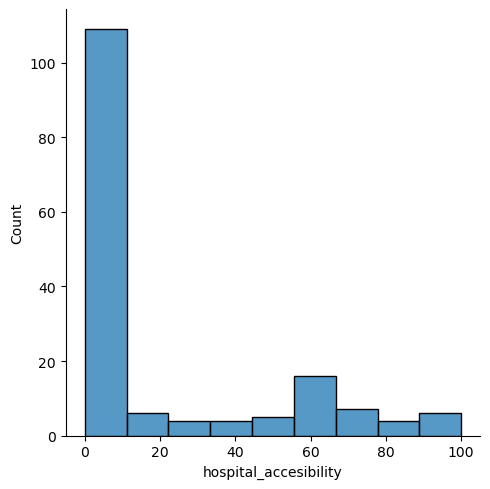

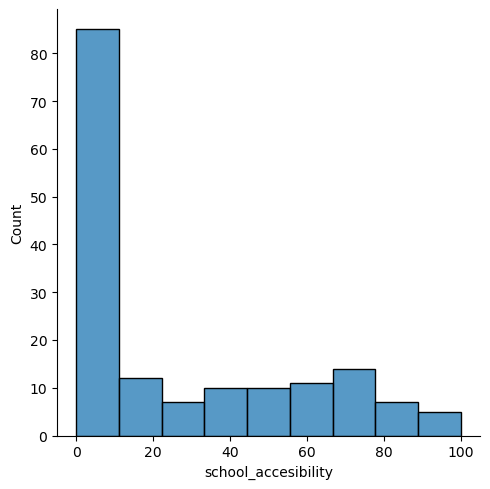

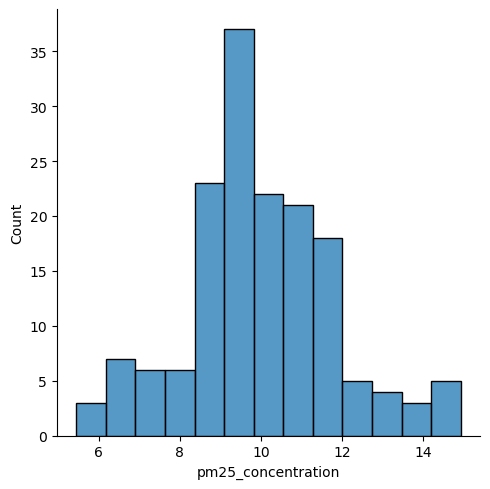

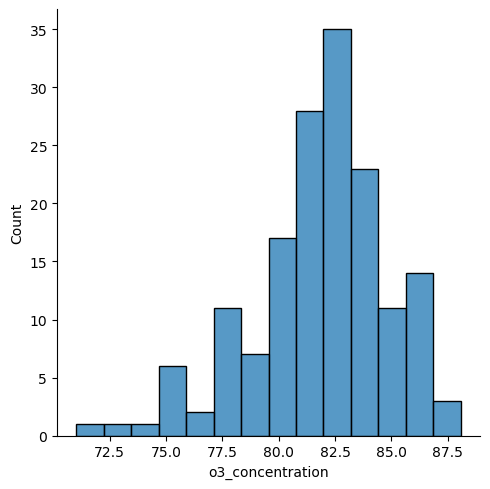

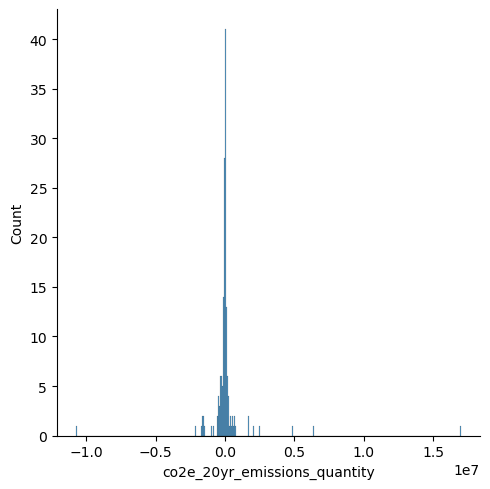

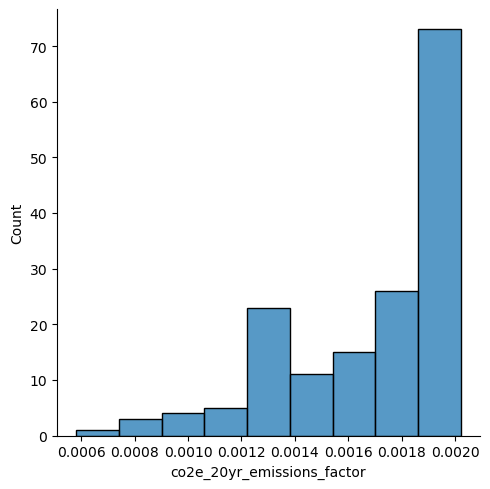

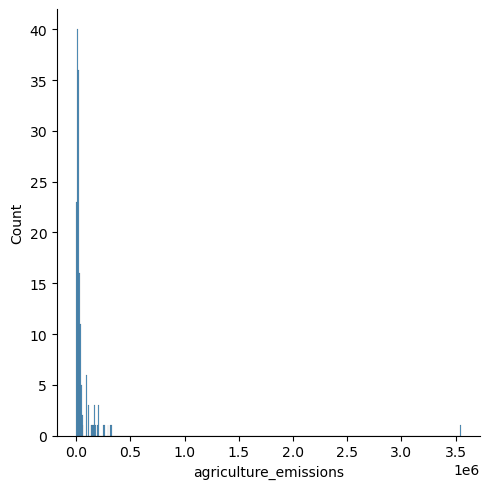

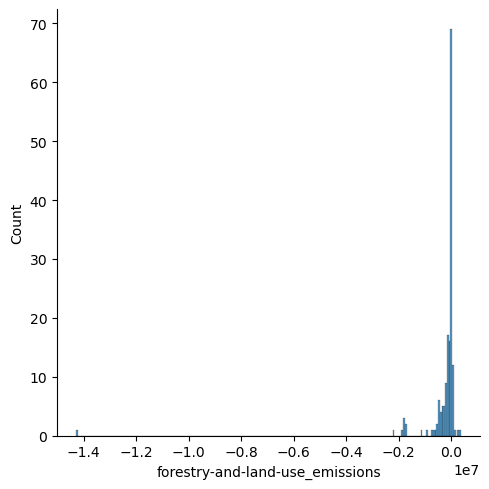

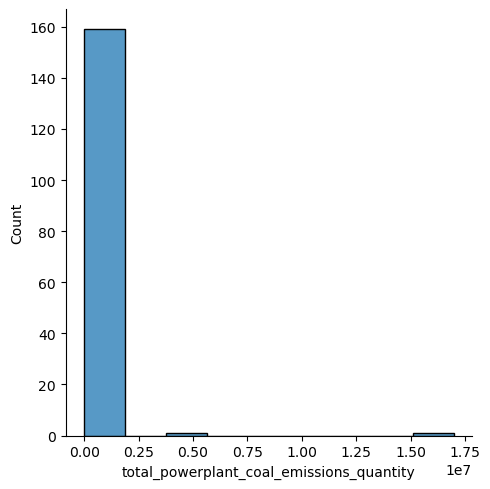

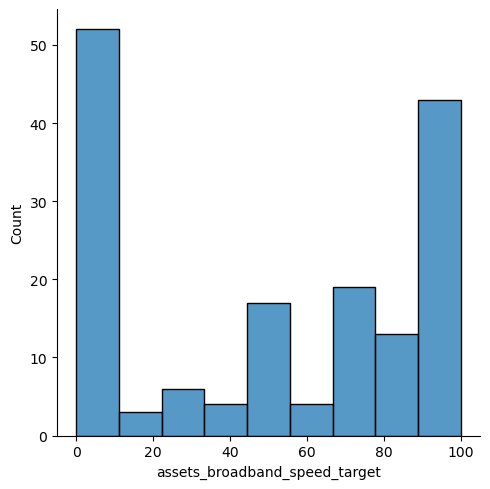

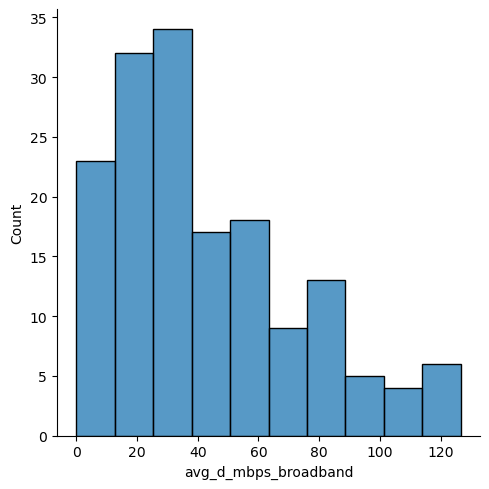

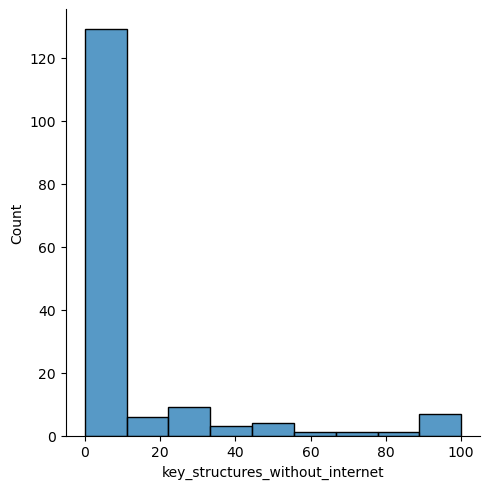

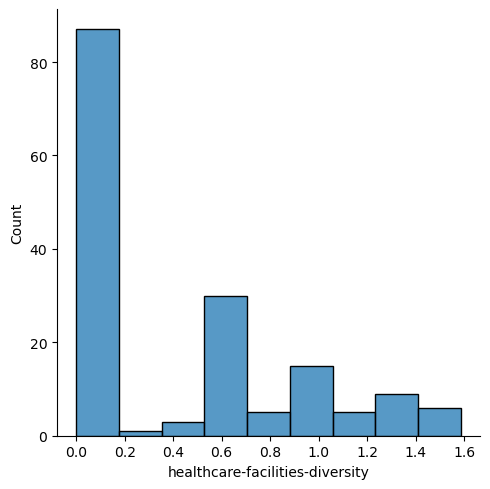

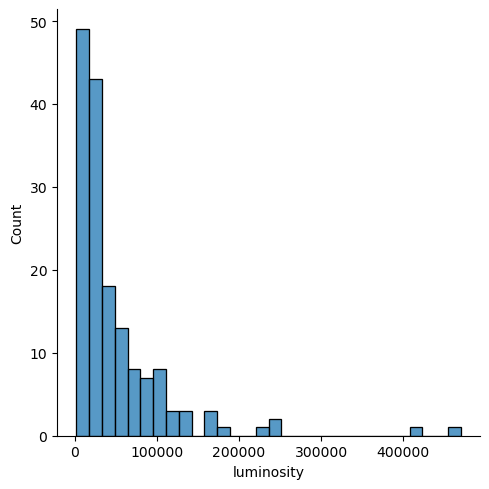

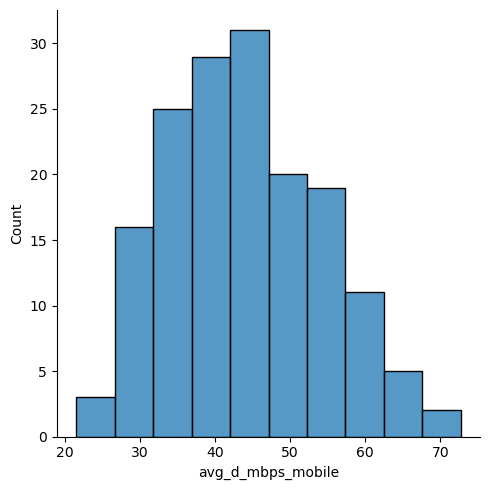

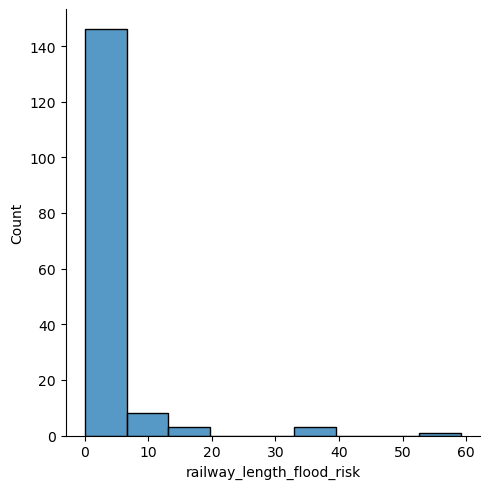

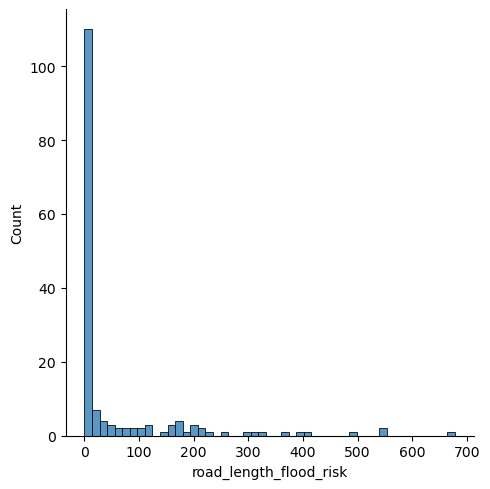

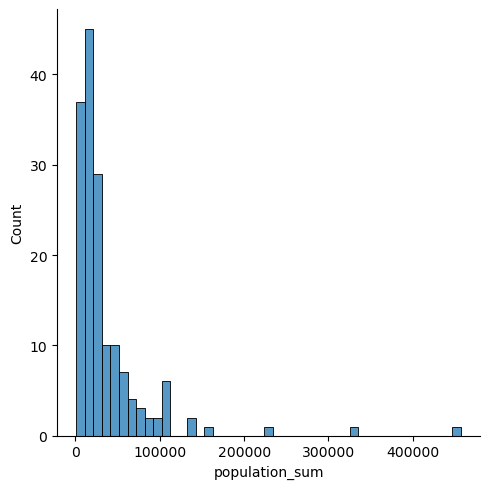

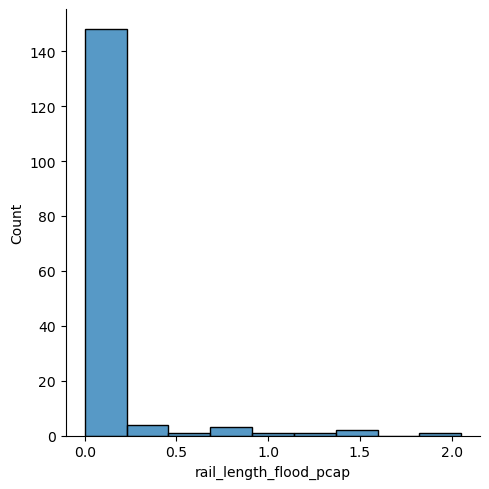

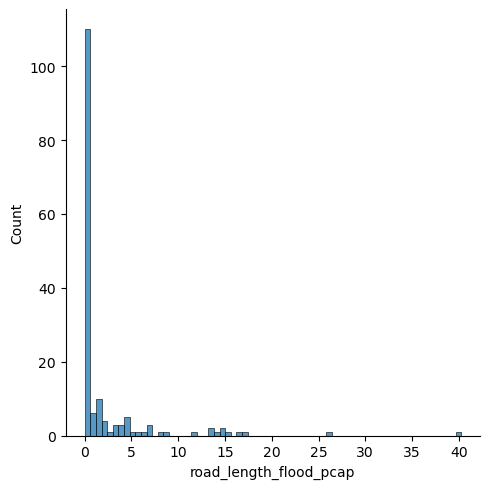

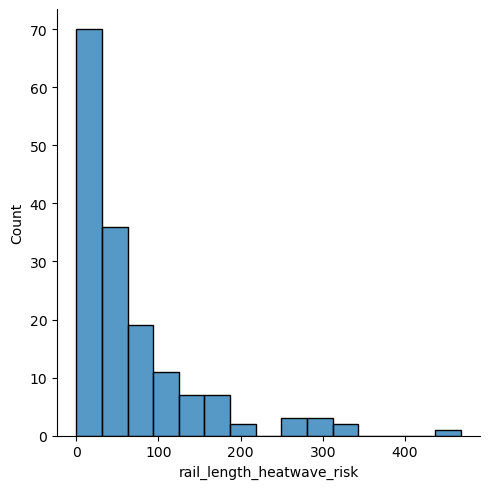

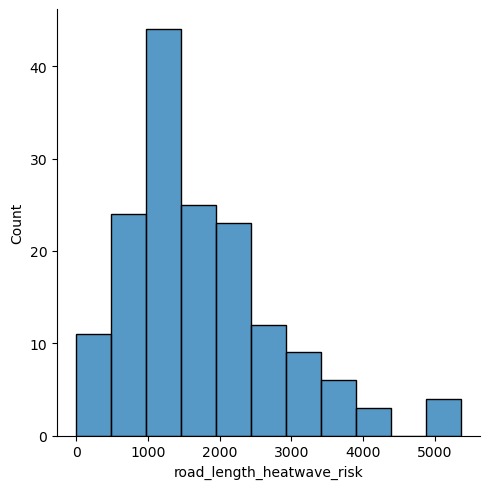

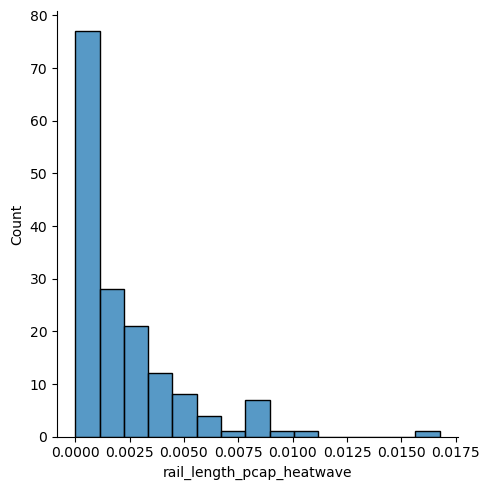

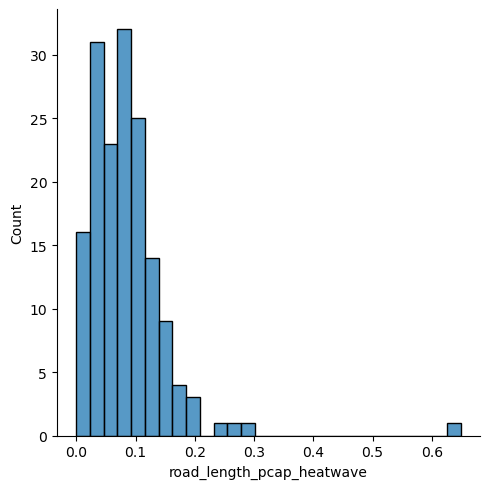

In [27]:
for col in df.drop(['GID_2', 'NAME_2', 'year'], axis=1).columns.to_list():
# for col in df.drop(['MUNICIPALITY_ID', 'MUNICIPALITY_NAME', 'DISTRICT_ID', 'DISTRICT_NAME', 'YEAR'], axis=1).columns.to_list():
    sns.displot(df[col])

In [28]:
poly = gpd.read_file("D:\Work\WB\LDT\countries\SRB\shapefiles\gadm41_SRB_2.json".replace('\\', '/'))
gdf = gpd.GeoDataFrame(pd.merge(df, poly[['GID_1', 'NAME_1', 'GID_2', 'NAME_2', 'geometry']], on=['GID_2', 'NAME_2'], how='left'))
gdf.head()

,GID_2,NAME_2,year,hospital_accesibility,school_accesibility,pm25_concentration,o3_concentration,co2e_20yr_emissions_quantity,co2e_20yr_emissions_factor,agriculture_emissions,forestry-and-land-use_emissions,total_powerplant_coal_emissions_quantity,assets_broadband_speed_target,avg_d_mbps_broadband,key_structures_without_internet,healthcare-facilities-diversity,luminosity,avg_d_mbps_mobile,railway_length_flood_risk,road_length_flood_risk,population_sum,rail_length_flood_pcap,road_length_flood_pcap,rail_length_heatwave_risk,road_length_heatwave_risk,rail_length_pcap_heatwave,road_length_pcap_heatwave,GID_1,NAME_1,geometry
0,SRB.1.1_1,Bor,2022,68.0,67.0,8.200826,83.223843,2.426913e+05,0.001949,34427.619023,-3.271693e+05,0.0,70.00,52.114375,0.000000,1.388204,49666.75,36.962571,0.00000,0.000000,36938.533333,0.000,0.000,91.160238,2990.901095,0.002468,0.080970,SRB.1_1,Borski,"MULTIPOLYGON (((21.9554 44.1779, 21.9912 44.17..."
1,SRB.1.2_1,Kladovo,2022,0.0,0.0,8.020168,82.699687,-4.477292e+05,0.001291,25194.353584,-4.797092e+05,0.0,100.00,59.009417,0.000000,-0.000000,22002.45,29.269801,0.00000,224.386815,16626.023529,0.000,13.496,0.000000,1389.346154,0.000000,0.083565,SRB.1_1,Borski,"MULTIPOLYGON (((22.6492 44.5411, 22.644 44.545..."
2,SRB.1.3_1,Majdanpek,2022,33.0,12.0,8.813018,81.591422,-4.353125e+05,0.001944,22611.298330,-4.671388e+05,0.0,50.00,48.167000,20.000000,1.039721,17438.50,43.221584,0.00000,115.498788,13804.294118,0.000,8.367,48.239500,2155.660005,0.003495,0.156159,SRB.1_1,Borski,"MULTIPOLYGON (((22.1915 44.4985, 22.1967 44.51..."
3,SRB.1.4_1,Negotin,2022,10.0,3.0,8.931743,79.895999,-1.574552e+06,0.001902,201050.222273,-1.775602e+06,0.0,0.00,18.188750,0.000000,0.759547,31368.90,40.925646,59.20766,394.397557,28860.266667,2.052,13.666,85.573661,2562.409002,0.002965,0.088787,SRB.1_1,Borski,"MULTIPOLYGON (((22.6851 44.2099, 22.6853 44.20..."
4,SRB.10.1_1,Aleksinac,2022,58.0,44.0,10.482962,85.749346,1.065689e+05,0.001839,29474.009024,7.709493e+04,0.0,15.87,20.851130,85.294118,1.141857,72620.00,39.859882,0.00000,162.341903,38180.529412,0.000,4.252,130.325627,2912.461398,0.003413,0.076281,SRB.10_1,Nišavski,"MULTIPOLYGON (((21.7019 43.3659, 21.6906 43.36..."


## Individual Indicators

### Population

<Axes: >

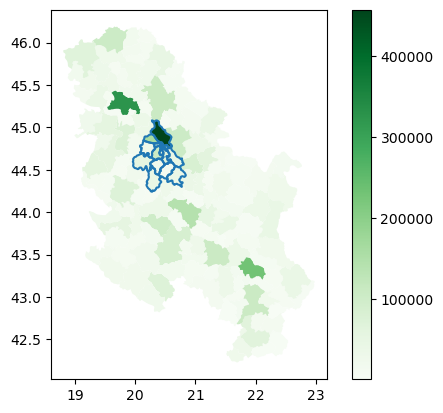

In [7]:
test = gdf[['GID_2', 'NAME_2', 'GID_1', 'NAME_1', 'population_sum', 'geometry']]

fig, ax = plt.subplots(ncols=1, nrows=1)
test.plot('population_sum', cmap='Greens', legend=True, ax=ax)
test[test['NAME_1'] == 'GradBeograd'].boundary.plot(ax=ax)

In [8]:
test.sort_values(by=['population_sum'], ascending=False)

,GID_2,NAME_2,GID_1,NAME_1,population_sum,geometry
115,SRB.3.8_1,Palilula,SRB.3_1,GradBeograd,456825.266667,"MULTIPOLYGON (((20.6101 44.782, 20.5846 44.774..."
131,SRB.5.6_1,NoviSad,SRB.5_1,Južno-Bački,325789.090196,"MULTIPOLYGON (((19.5335 45.2406, 19.5515 45.24..."
8,SRB.10.5_1,Niš,SRB.10_1,Nišavski,231101.909804,"MULTIPOLYGON (((21.7019 43.3659, 21.7398 43.37..."
106,SRB.3.16_1,Zemun,SRB.3_1,GradBeograd,161958.047059,"MULTIPOLYGON (((20.4265 44.8006, 20.4148 44.80..."
74,SRB.21.4_1,Kragujevac,SRB.21_1,Šumadijski,142405.372549,"MULTIPOLYGON (((20.6369 44.0202, 20.6235 44.03..."
...,...,...,...,...,...,...
121,SRB.4.5_1,Medveđa,SRB.4_1,Jablanički,6083.450980,"MULTIPOLYGON (((21.6851 42.6806, 21.6692 42.67..."
11,SRB.11.1_1,Bosilegrad,SRB.11_1,Pčinjski,6021.258824,"MULTIPOLYGON (((22.532 42.4767, 22.5316 42.472..."
33,SRB.15.3_1,Ćićevac,SRB.15_1,Rasinski,5637.725490,"MULTIPOLYGON (((21.4659 43.7494, 21.4715 43.74..."
15,SRB.11.5_1,Trgovište,SRB.11_1,Pčinjski,4348.376471,"MULTIPOLYGON (((22.2734 42.3379, 22.2532 42.33..."


### Hospital Accesibility

c:\Users\sonle\anaconda3\envs\wb-ldt\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


<Axes: >

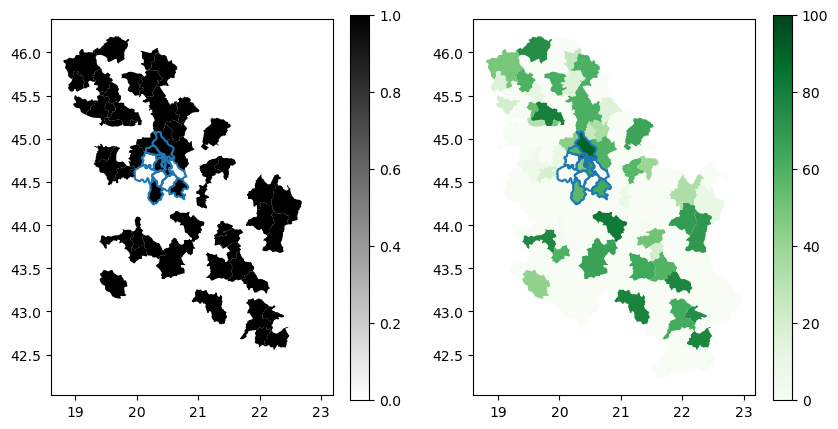

In [9]:
test = gdf[['GID_2', 'NAME_2', 'GID_1', 'NAME_1', 'hospital_accesibility', 'geometry']]
test['on_off'] = np.where(test['hospital_accesibility'] > 0, 1, 0)

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=[10, 5])
test.plot('on_off', cmap='binary', legend=True, ax=ax[0])
test[test['NAME_1'] == 'GradBeograd'].boundary.plot(ax=ax[0])

test.plot('hospital_accesibility', cmap='Greens', legend=True, ax=ax[1])
test[test['NAME_1'] == 'GradBeograd'].boundary.plot(ax=ax[1])

In [14]:
len(test[test['on_off'] == 0]) / len(test)

0.6086956521739131

* ~60% of all municipalties in Serbia do not have access to hospitals according to our current formula
* Not all municipalties within the Belgrade area seem to have hospital access. 
* Can we assume that residents within the ones who don't are able to travel to nearby municipalities to receieve health services?
* Does the same logic apply to other, non-Belgrade municipalties? Or, do we need to have more context to get a clearer answer?

### School Accessibility

c:\Users\sonle\anaconda3\envs\wb-ldt\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


<Axes: >

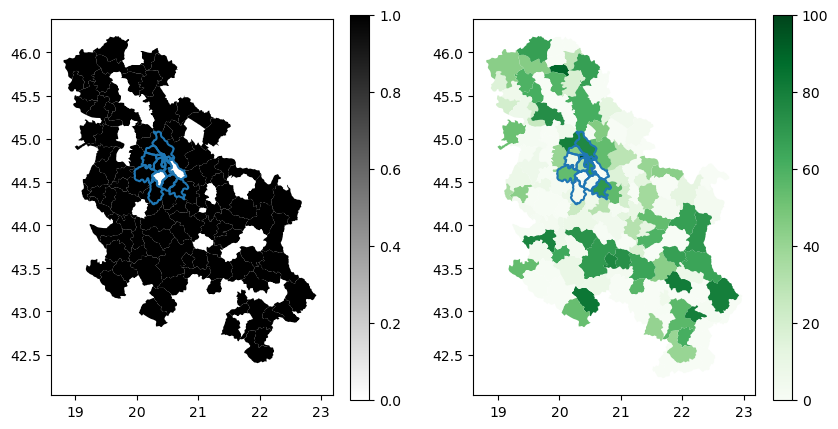

In [32]:
test = gdf[['GID_2', 'NAME_2', 'GID_1', 'NAME_1', 'school_accesibility', 'geometry']]
test['on_off'] = np.where(test['school_accesibility'] > 0, 1, 0)

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=[10, 5])
test.plot('on_off', cmap='binary', legend=True, ax=ax[0])
test[test['NAME_1'] == 'GradBeograd'].boundary.plot(ax=ax[0])

test.plot('school_accesibility', cmap='Greens', legend=True, ax=ax[1])
test[test['NAME_1'] == 'GradBeograd'].boundary.plot(ax=ax[1])

* Similar observation with school accessibility, but there are significantly fewer municipalities without school accessibility (25%) than hospital
* The lack of school access serem to be concentrated in the Northwestern and Southern parts of Serbia

### Air Quality

c:\Users\sonle\anaconda3\envs\wb-ldt\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


<Axes: >

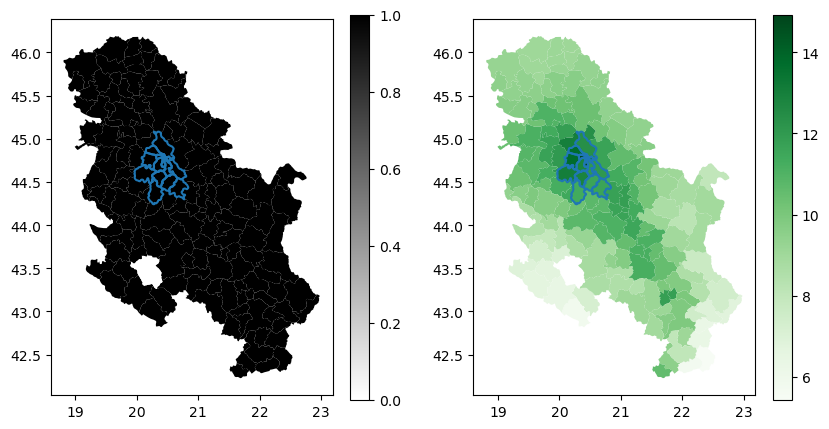

In [29]:
test = gdf[['GID_2', 'NAME_2', 'GID_1', 'NAME_1', 'pm25_concentration', 'geometry']]
test['on_off'] = np.where(test['pm25_concentration'] > 5, 1, 0)

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=[10,5])
test.plot('on_off', cmap='binary', legend=True, ax=ax[0])
test[test['NAME_1'] == 'GradBeograd'].boundary.plot(ax=ax[0])


test.plot('pm25_concentration', cmap='Greens', legend=True, ax=ax[1])
test[test['NAME_1'] == 'GradBeograd'].boundary.plot(ax=ax[1])

### Digitalization

c:\Users\sonle\anaconda3\envs\wb-ldt\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


<Axes: >

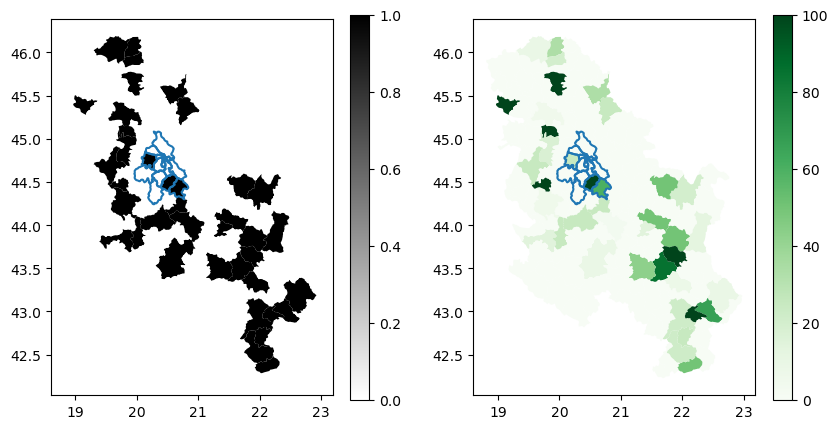

In [36]:
test = gdf[['GID_2', 'NAME_2', 'GID_1', 'NAME_1', 'key_structures_without_internet', 'geometry']]
test['on_off'] = np.where(test['key_structures_without_internet'] > 0, 1, 0)

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=[10,5])
test.plot('on_off', cmap='binary', legend=True, ax=ax[0])
test[test['NAME_1'] == 'GradBeograd'].boundary.plot(ax=ax[0])


test.plot('key_structures_without_internet', cmap='Greens', legend=True, ax=ax[1])
test[test['NAME_1'] == 'GradBeograd'].boundary.plot(ax=ax[1])

<Axes: >

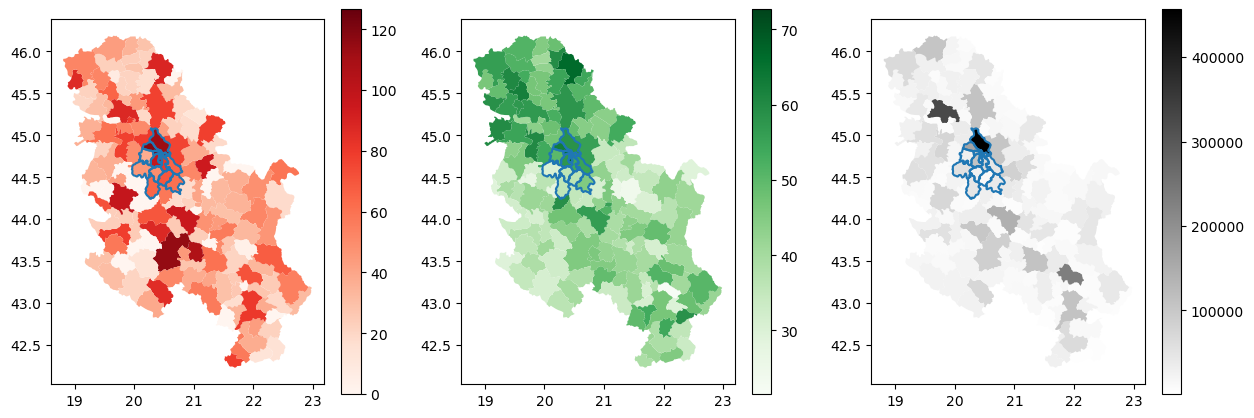

In [40]:
test = gdf[['GID_2', 'NAME_2', 'GID_1', 'NAME_1', 'avg_d_mbps_broadband', 'avg_d_mbps_mobile', 'population_sum', 'geometry']]
# test['on_off'] = np.where(test['key_structures_without_internet'] > 0, 1, 0)

fig, ax = plt.subplots(ncols=3, nrows=1, figsize=[15,5])
test.plot('avg_d_mbps_broadband', cmap='Reds', legend=True, ax=ax[0])
test[test['NAME_1'] == 'GradBeograd'].boundary.plot(ax=ax[0])


test.plot('avg_d_mbps_mobile', cmap='Greens', legend=True, ax=ax[1])
test[test['NAME_1'] == 'GradBeograd'].boundary.plot(ax=ax[1])

test.plot('population_sum', cmap='binary', legend=True, ax=ax[2])
test[test['NAME_1'] == 'GradBeograd'].boundary.plot(ax=ax[2])

* Clear distinction in mobile internet speeds among the Northern and Southern regions of Serbia
* There seems to be a correlation between population size and broadband internet speeds
* May need to cross reference with GDP / GDP per capita to find correlation 
* Will need to cross-reference with sample sizes from Ookla data

### Nighttime Luminosity

c:\Users\sonle\anaconda3\envs\wb-ldt\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


<Axes: >

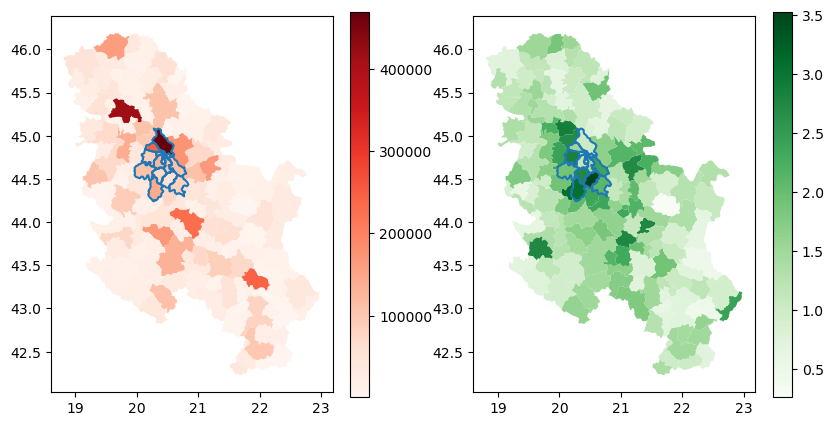

In [38]:
test = gdf[['GID_2', 'NAME_2', 'GID_1', 'NAME_1', 'luminosity', 'population_sum', 'geometry']]
test['luminosity_pcap'] = test['luminosity'] / test['population_sum']

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=[10,5])
test.plot('luminosity', cmap='Reds', legend=True, ax=ax[0])
test[test['NAME_1'] == 'GradBeograd'].boundary.plot(ax=ax[0])


test.plot('luminosity_pcap', cmap='Greens', legend=True, ax=ax[1])
test[test['NAME_1'] == 'GradBeograd'].boundary.plot(ax=ax[1])

### Rail 

<Axes: >

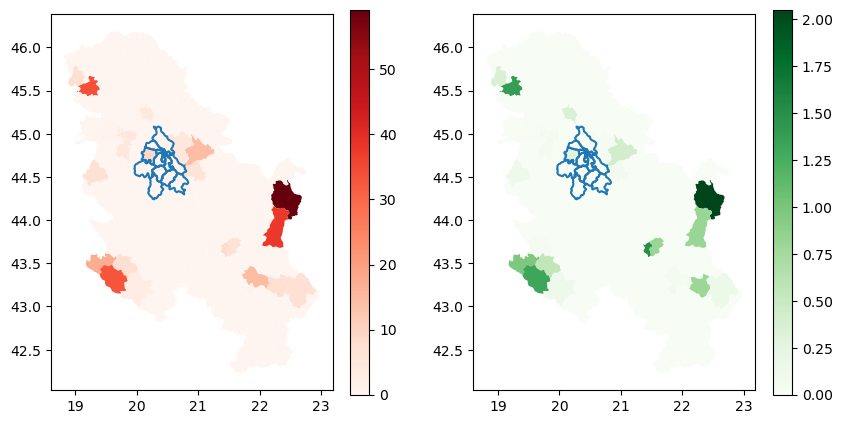

In [29]:
test = gdf[['GID_2', 'NAME_2', 'GID_1', 'NAME_1', 'railway_length_flood_risk', 'rail_length_flood_pcap', 'geometry']]

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=[10,5])
test.plot('railway_length_flood_risk', cmap='Reds', legend=True, ax=ax[0])
test[test['NAME_1'] == 'GradBeograd'].boundary.plot(ax=ax[0])


test.plot('rail_length_flood_pcap', cmap='Greens', legend=True, ax=ax[1])
test[test['NAME_1'] == 'GradBeograd'].boundary.plot(ax=ax[1])



In [ ]:
gdf['railway_length_flood_risk'].sum()

np.float64(303.8313198756722)

<Axes: >

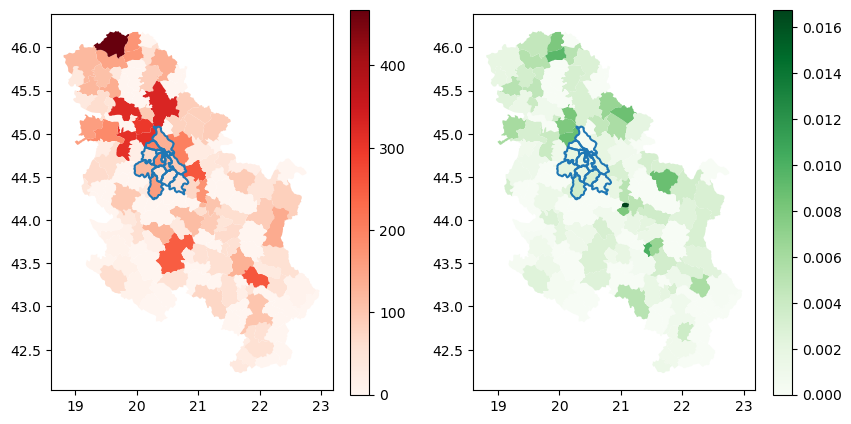

In [30]:
test = gdf[['GID_2', 'NAME_2', 'GID_1', 'NAME_1', 'rail_length_heatwave_risk', 'rail_length_pcap_heatwave', 'geometry']]

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=[10,5])
test.plot('rail_length_heatwave_risk', cmap='Reds', legend=True, ax=ax[0])
test[test['NAME_1'] == 'GradBeograd'].boundary.plot(ax=ax[0])


test.plot('rail_length_pcap_heatwave', cmap='Greens', legend=True, ax=ax[1])
test[test['NAME_1'] == 'GradBeograd'].boundary.plot(ax=ax[1])



In [35]:
gdf['rail_length_heatwave_risk'].sum()

np.float64(10155.016683733498)

### Roads

<Axes: >

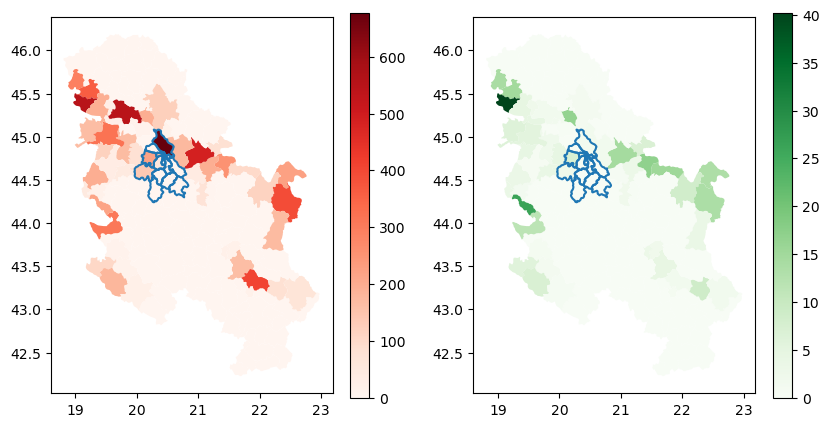

In [31]:
test = gdf[['GID_2', 'NAME_2', 'GID_1', 'NAME_1', 'road_length_flood_risk', 'road_length_flood_pcap', 'geometry']]

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=[10,5])
test.plot('road_length_flood_risk', cmap='Reds', legend=True, ax=ax[0])
test[test['NAME_1'] == 'GradBeograd'].boundary.plot(ax=ax[0])


test.plot('road_length_flood_pcap', cmap='Greens', legend=True, ax=ax[1])
test[test['NAME_1'] == 'GradBeograd'].boundary.plot(ax=ax[1])



<Axes: >

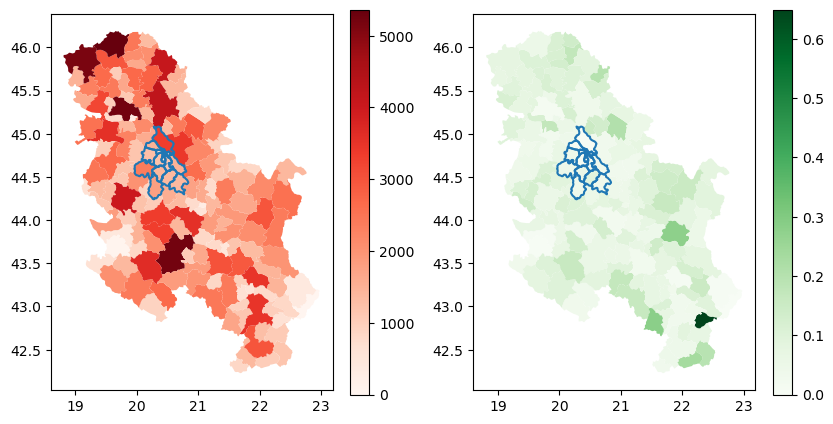

In [32]:
test = gdf[['GID_2', 'NAME_2', 'GID_1', 'NAME_1', 'road_length_heatwave_risk', 'road_length_pcap_heatwave', 'geometry']]

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=[10,5])
test.plot('road_length_heatwave_risk', cmap='Reds', legend=True, ax=ax[0])
test[test['NAME_1'] == 'GradBeograd'].boundary.plot(ax=ax[0])


test.plot('road_length_pcap_heatwave', cmap='Greens', legend=True, ax=ax[1])
test[test['NAME_1'] == 'GradBeograd'].boundary.plot(ax=ax[1])

